In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/felasofarahmatanti/data-sales/Sales.csv


   Period    Sales
0       1  10618.1
1       2  10537.9
2       3  10209.3
3       4  10553.0
4       5   9934.9
     Period    Sales
115     116  10650.0
116     117  10741.6
117     118  10246.0
118     119  10354.4
119     120  10155.4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Period  120 non-null    int64  
 1   Sales   120 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.0 KB
None

Jumlah observasi = 120


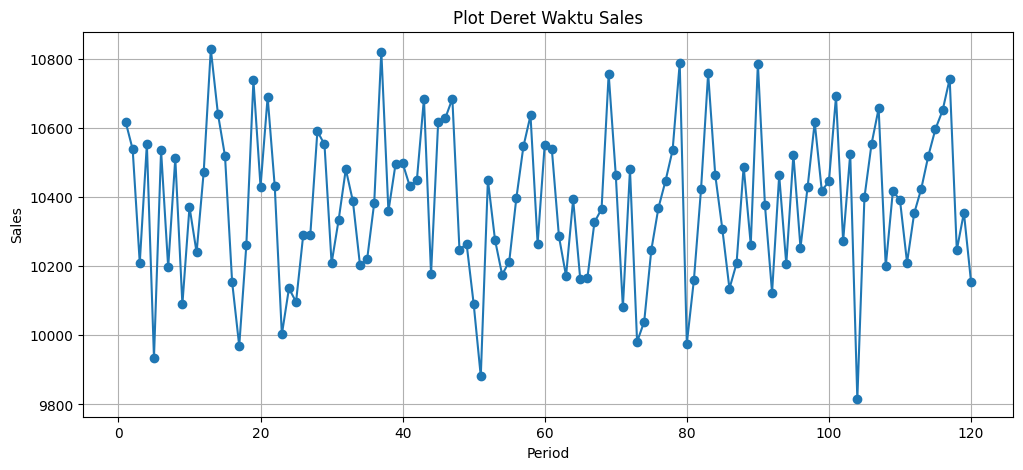


Jumlah data training = 96
Jumlah data testing  = 24

PARAMETER SINGLE EXPONENTIAL SMOOTHING
Alpha = 1.4901161193847656e-08

PARAMETER DOUBLE EXPONENTIAL SMOOTHING
Alpha = 1.4901161193847656e-08
Beta = 0.0

HASIL PERBANDINGAN METODE
                         Metode  MAPE Training (%)  MAPE Testing (%)
2  Single Exponential Smoothing             1.7571            1.5667
3  Double Exponential Smoothing             1.7536            1.6524
0         Single Moving Average             2.0932            1.8810
1         Double Moving Average             2.6678            2.1207

METODE TERBAIK
Metode = Single Exponential Smoothing
MAPE Training = 1.7571 %
MAPE Testing = 1.5667 %


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the

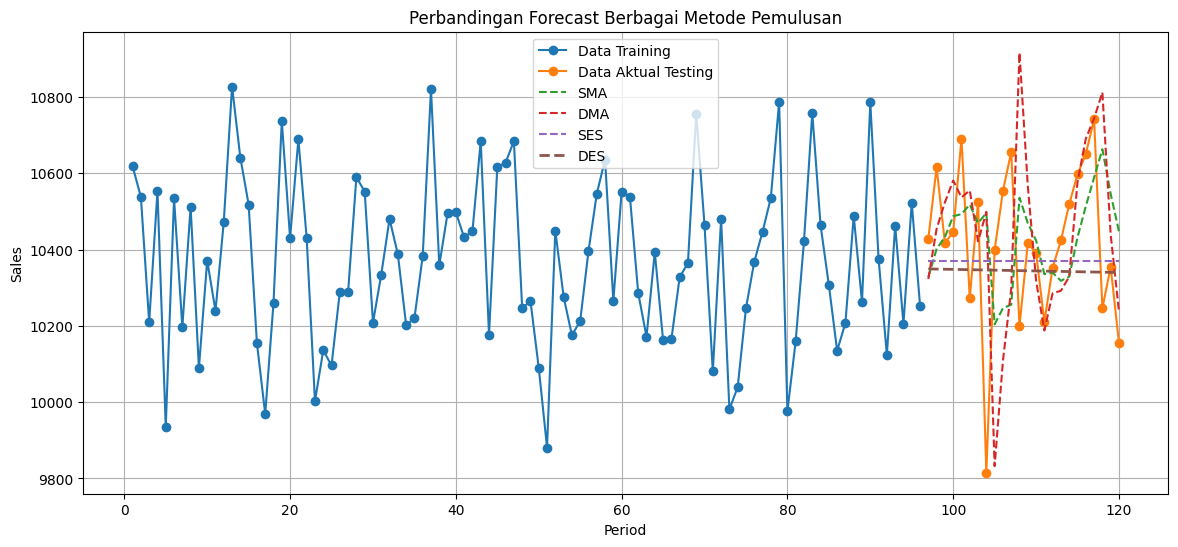

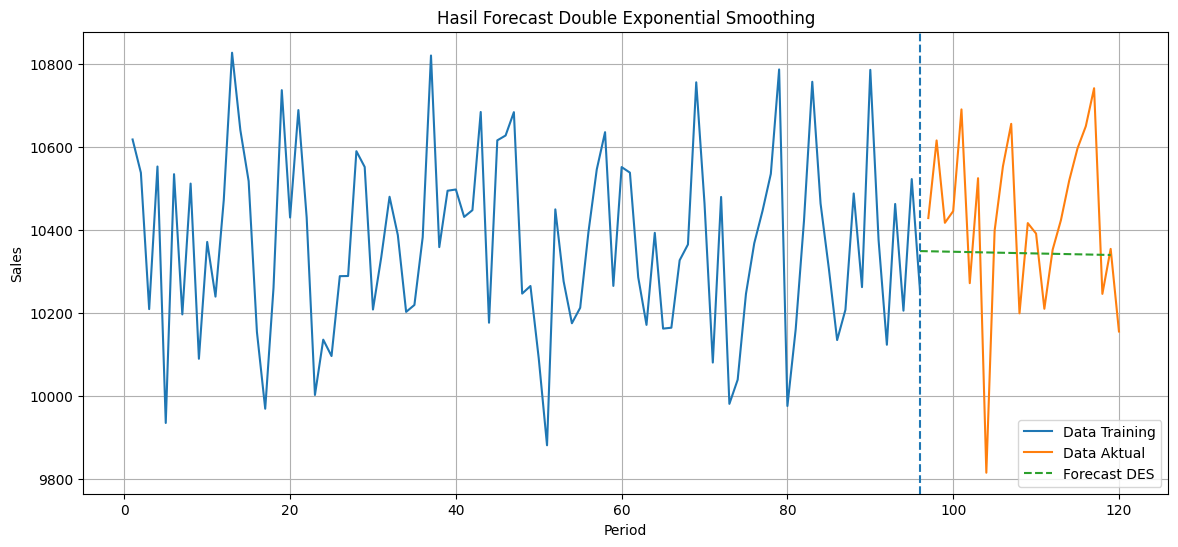

In [2]:
# ============================================================
# ANALISIS PEMULUSAN DATA TIME SERIES
# Data: Sales.csv
#
# Metode:
# 1. Single Moving Average (SMA)
# 2. Double Moving Average (DMA)
# 3. Single Exponential Smoothing (SES)
# 4. Double Exponential Smoothing (DES / Holt)
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARY
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt
)


# ------------------------------------------------------------
# 2. MEMBACA DATA
# ------------------------------------------------------------
path = "/kaggle/input/datasets/felasofarahmatanti/data-sales/Sales.csv"

data = pd.read_csv(path)

print(data.head())
print(data.tail())
print(data.info())

# ------------------------------------------------------------
# 3. MENJADIKAN PERIOD SEBAGAI INDEX
# ------------------------------------------------------------

data = data.sort_values("Period")

data = data.set_index("Period")

y = data["Sales"]

print("\nJumlah observasi =", len(y))


# ------------------------------------------------------------
# 4. VISUALISASI DATA AWAL
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    y.index,
    y.values,
    marker="o"
)

plt.title("Plot Deret Waktu Sales")
plt.xlabel("Period")
plt.ylabel("Sales")

plt.grid()

plt.show()


# ------------------------------------------------------------
# 5. MEMBAGI DATA TRAIN DAN TEST
# ------------------------------------------------------------

# Menggunakan 80% data sebagai training
# dan 20% data sebagai testing

train_size = int(len(y) * 0.80)

train = y.iloc[:train_size]
test = y.iloc[train_size:]

print("\nJumlah data training =", len(train))
print("Jumlah data testing  =", len(test))


# ------------------------------------------------------------
# 6. FUNGSI MAPE
# ------------------------------------------------------------

def MAPE(actual, predicted):

    actual = np.array(actual)
    predicted = np.array(predicted)

    # Menghilangkan observasi dengan nilai aktual 0
    mask = actual != 0

    actual = actual[mask]
    predicted = predicted[mask]

    return np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100


# ============================================================
# 7. SINGLE MOVING AVERAGE (SMA)
# ============================================================

# Ukuran window
n = 3


# ------------------------------------------------------------
# PREDIKSI TRAINING SMA
# ------------------------------------------------------------

sma_train_pred = train.rolling(
    window=n
).mean().shift(1)


# Menghapus NA
valid_sma = sma_train_pred.notna()

mape_sma_train = MAPE(
    train[valid_sma],
    sma_train_pred[valid_sma]
)


# ------------------------------------------------------------
# PREDIKSI TESTING SMA
# ------------------------------------------------------------

history = list(train.values)

sma_test_pred = []

for actual in test.values:

    forecast = np.mean(
        history[-n:]
    )

    sma_test_pred.append(forecast)

    # Menambahkan nilai aktual
    history.append(actual)


sma_test_pred = np.array(sma_test_pred)


mape_sma_test = MAPE(
    test.values,
    sma_test_pred
)


# ============================================================
# 8. DOUBLE MOVING AVERAGE (DMA)
# ============================================================

# ------------------------------------------------------------
# PREDIKSI TRAINING DMA
# ------------------------------------------------------------

# Moving average pertama
ma1 = train.rolling(
    window=n
).mean()

# Moving average kedua
ma2 = ma1.rolling(
    window=n
).mean()


# Parameter level
a = 2 * ma1 - ma2


# Parameter trend
b = (
    2 / (n - 1)
) * (
    ma1 - ma2
)


# Forecast satu periode ke depan
dma_train_pred = (
    a.shift(1) +
    b.shift(1)
)


valid_dma = dma_train_pred.notna()


mape_dma_train = MAPE(
    train[valid_dma],
    dma_train_pred[valid_dma]
)


# ------------------------------------------------------------
# PREDIKSI TESTING DMA
# ------------------------------------------------------------

history = list(train.values)

dma_test_pred = []


for actual in test.values:

    history_series = pd.Series(history)

    # Moving average pertama
    ma1_temp = history_series.rolling(
        window=n
    ).mean()

    # Moving average kedua
    ma2_temp = ma1_temp.rolling(
        window=n
    ).mean()

    # Nilai MA terakhir
    ma1_last = ma1_temp.dropna().iloc[-1]

    ma2_last = ma2_temp.dropna().iloc[-1]


    # Parameter level
    a_last = (
        2 * ma1_last -
        ma2_last
    )


    # Parameter trend
    b_last = (
        2 / (n - 1)
    ) * (
        ma1_last -
        ma2_last
    )


    # Forecast satu periode ke depan
    forecast = a_last + b_last

    dma_test_pred.append(forecast)

    # Tambahkan data aktual ke history
    history.append(actual)


dma_test_pred = np.array(
    dma_test_pred
)


mape_dma_test = MAPE(
    test.values,
    dma_test_pred
)


# ============================================================
# 9. SINGLE EXPONENTIAL SMOOTHING
# ============================================================

ses_model = SimpleExpSmoothing(
    train,
    initialization_method="estimated"
).fit(
    optimized=True
)


# Nilai fitted pada training
ses_train_pred = ses_model.fittedvalues


# Forecast testing
ses_test_pred = ses_model.forecast(
    len(test)
)


# Menghitung MAPE training
mape_ses_train = MAPE(
    train.values,
    ses_train_pred.values
)


# Menghitung MAPE testing
mape_ses_test = MAPE(
    test.values,
    ses_test_pred.values
)


# ============================================================
# 10. DOUBLE EXPONENTIAL SMOOTHING
#     HOLT'S METHOD
# ============================================================

des_model = Holt(
    train,
    initialization_method="estimated"
).fit(
    optimized=True
)


# Nilai fitted training
des_train_pred = des_model.fittedvalues


# Forecast testing
des_test_pred = des_model.forecast(
    len(test)
)


# MAPE training
mape_des_train = MAPE(
    train.values,
    des_train_pred.values
)


# MAPE testing
mape_des_test = MAPE(
    test.values,
    des_test_pred.values
)


# ============================================================
# 11. MENAMPILKAN PARAMETER SES DAN DES
# ============================================================

print("\n======================================")
print("PARAMETER SINGLE EXPONENTIAL SMOOTHING")
print("======================================")

print(
    "Alpha =",
    ses_model.params["smoothing_level"]
)


print("\n======================================")
print("PARAMETER DOUBLE EXPONENTIAL SMOOTHING")
print("======================================")

print(
    "Alpha =",
    des_model.params["smoothing_level"]
)

print(
    "Beta =",
    des_model.params["smoothing_trend"]
)


# ============================================================
# 12. TABEL PERBANDINGAN MAPE
# ============================================================

hasil = pd.DataFrame({

    "Metode": [

        "Single Moving Average",

        "Double Moving Average",

        "Single Exponential Smoothing",

        "Double Exponential Smoothing"

    ],

    "MAPE Training (%)": [

        mape_sma_train,

        mape_dma_train,

        mape_ses_train,

        mape_des_train

    ],

    "MAPE Testing (%)": [

        mape_sma_test,

        mape_dma_test,

        mape_ses_test,

        mape_des_test

    ]

})


# Membulatkan nilai
hasil = hasil.round(4)


# Urutkan berdasarkan MAPE Testing
hasil = hasil.sort_values(
    by="MAPE Testing (%)",
    ascending=True
)


print("\n======================================")
print("HASIL PERBANDINGAN METODE")
print("======================================")

print(hasil)


# ============================================================
# 13. METODE TERBAIK
# ============================================================

metode_terbaik = hasil.iloc[0]

print("\n======================================")
print("METODE TERBAIK")
print("======================================")

print(
    "Metode =",
    metode_terbaik["Metode"]
)

print(
    "MAPE Training =",
    metode_terbaik["MAPE Training (%)"],
    "%"
)

print(
    "MAPE Testing =",
    metode_terbaik["MAPE Testing (%)"],
    "%"
)


# ============================================================
# 14. VISUALISASI DATA TRAIN DAN TEST
# ============================================================

plt.figure(figsize=(14, 6))


# Data training
plt.plot(
    train.index,
    train.values,
    label="Data Training",
    marker="o"
)


# Data testing
plt.plot(
    test.index,
    test.values,
    label="Data Aktual Testing",
    marker="o"
)


# SMA
plt.plot(
    test.index,
    sma_test_pred,
    linestyle="--",
    label="SMA"
)


# DMA
plt.plot(
    test.index,
    dma_test_pred,
    linestyle="--",
    label="DMA"
)


# SES
plt.plot(
    test.index,
    ses_test_pred,
    linestyle="--",
    label="SES"
)


# DES
plt.plot(
    test.index,
    des_test_pred,
    linestyle="--",
    linewidth=2,
    label="DES"
)


plt.title(
    "Perbandingan Forecast Berbagai Metode Pemulusan"
)

plt.xlabel("Period")

plt.ylabel("Sales")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 15. VISUALISASI KHUSUS DOUBLE EXPONENTIAL SMOOTHING
# ============================================================

plt.figure(figsize=(14, 6))


plt.plot(
    train.index,
    train.values,
    label="Data Training"
)


plt.plot(
    test.index,
    test.values,
    label="Data Aktual"
)


plt.plot(
    des_test_pred.index,
    des_test_pred.values,
    linestyle="--",
    label="Forecast DES"
)


plt.axvline(
    x=train.index[-1],
    linestyle="--"
)


plt.title(
    "Hasil Forecast Double Exponential Smoothing"
)

plt.xlabel("Period")

plt.ylabel("Sales")

plt.legend()

plt.grid()

plt.show()



In [3]:
# 1. Persiapan Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt

# Membaca data
data = pd.read_csv("/kaggle/input/datasets/felasofarahmatanti/data-sales/Sales.csv")

# Pastikan urut berdasarkan periode
smoothing = data.sort_values("Period").reset_index(drop=True)

print(smoothing.head())
print(smoothing.tail())

# Menghitung ukuran data
data_size = len(smoothing)

# Menghitung indeks untuk pembagian data latih dan data uji (75% untuk latih, 25% untuk uji)
train_size = int(data_size * 0.80)

# Membagi data menjadi data latih dan data uji
train_data_sma = smoothing.iloc[:train_size]
test_data_sma = smoothing.iloc[train_size:]

print(f"Ukuran data asli: {data_size}")
print(f"Ukuran data latih: {len(train_data_sma)}")
print(f"Ukuran data uji: {len(test_data_sma)}")


   Period    Sales
0       1  10618.1
1       2  10537.9
2       3  10209.3
3       4  10553.0
4       5   9934.9
     Period    Sales
115     116  10650.0
116     117  10741.6
117     118  10246.0
118     119  10354.4
119     120  10155.4
Ukuran data asli: 120
Ukuran data latih: 96
Ukuran data uji: 24


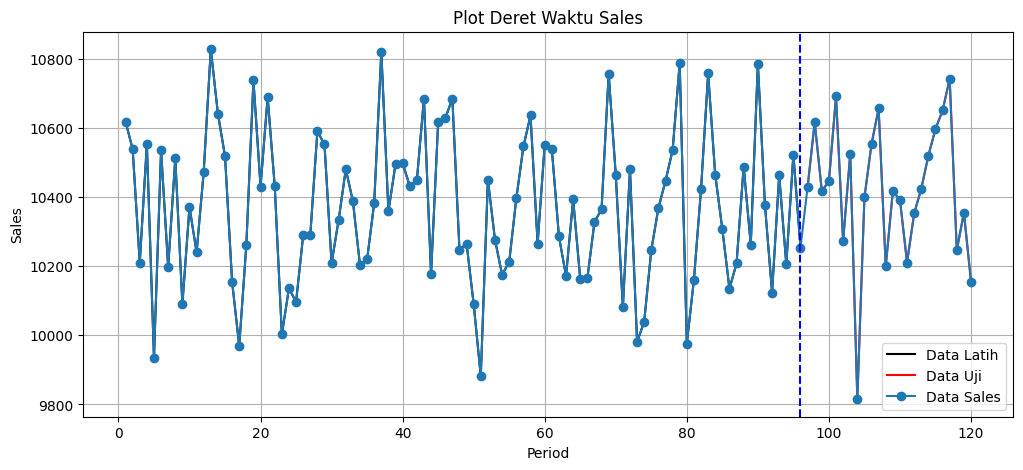

In [4]:
# Visualisasi data asli:
plt.figure(figsize=(12, 5))
plt.plot(train_data_sma.Period, train_data_sma.Sales, color='black', label='Data Latih')
plt.plot(test_data_sma.Period, test_data_sma.Sales, color='red', label='Data Uji')

plt.plot(
    data["Period"],
    data["Sales"],
    marker="o",
    label="Data Sales"
)
# Menambahkan garis vertikal pada titik pembagian
plt.axvline(x=train_data_sma.Period.iloc[-1], color='blue', linestyle='--')


plt.xlabel("Period")
plt.ylabel("Sales")
plt.title("Plot Deret Waktu Sales")
plt.legend()
plt.grid(True)

plt.show()

   Period    Sales           SMA
0       1  10618.1           NaN
1       2  10537.9           NaN
2       3  10209.3  10455.100000
3       4  10553.0  10433.400000
4       5   9934.9  10232.400000
5       6  10534.5  10340.800000
6       7  10196.5  10221.966667
7       8  10511.8  10414.266667
8       9  10089.6  10265.966667
9      10  10371.2  10324.200000


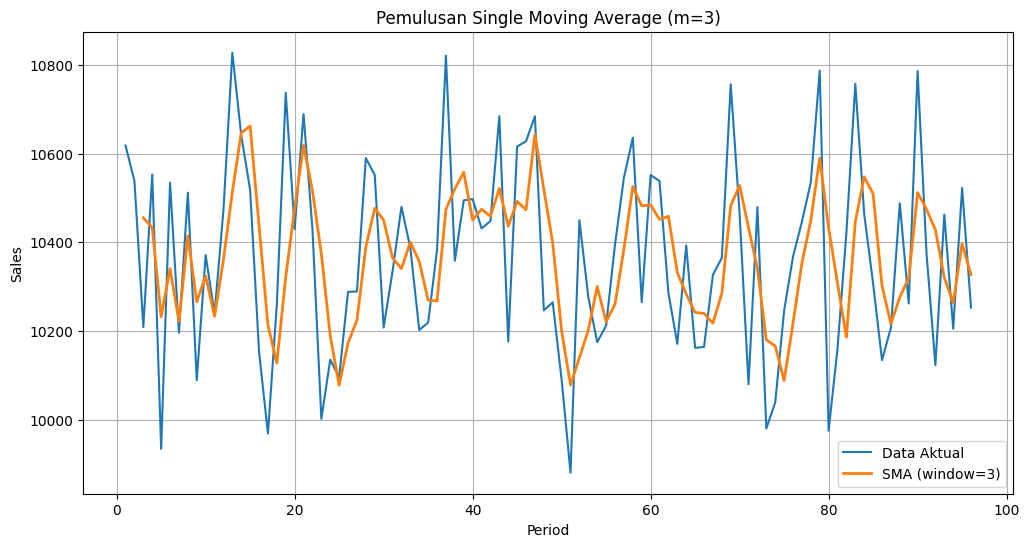

In [5]:
# A. SINGLE MOVING AVERAGE (SMA)
# Tahap 1: Pemulusan SMA
window = 3

train_data_sma = train_data_sma.copy()

train_data_sma["SMA"] = (
    train_data_sma["Sales"]
    .rolling(window=window)
    .mean()
)

print(train_data_sma.head(10))

#Plot data asli dan SMA
plt.figure(figsize=(12, 6))

plt.plot(
    train_data_sma["Period"],
    train_data_sma["Sales"],
    label="Data Aktual"
)

plt.plot(
    train_data_sma["Period"],
    train_data_sma["SMA"],
    label=f"SMA (window={window})",
    linewidth=2
)

plt.xlabel("Period")
plt.ylabel("Sales")
plt.title(f"Pemulusan Single Moving Average (m={window})")

plt.legend()
plt.grid(True)

plt.show()

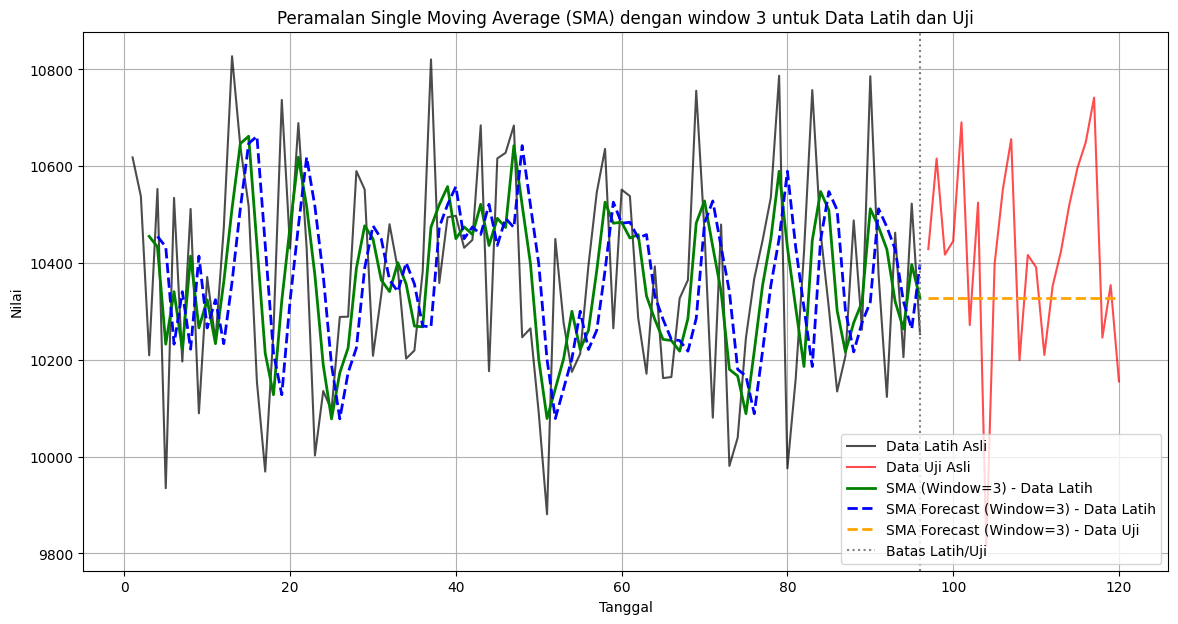

In [6]:
# Peramalan SMA pada Data Train
train_data_forecast = pd.Series(
    train_data_sma['SMA'].shift(1),
    index=train_data_sma.index
)
# Untuk peramalan multi-langkah dengan SMA, pendekatan paling sederhana adalah
# memperpanjang nilai SMA terakhir dari data latih untuk seluruh periode uji.
# Ini adalah metode SMA terakhir hasil data latih dijadikan forecast seluruh test
# sehingga pada data test plot berupa garis lurus


#Permalan data test dengan nilai sma tetap untuk seluruh forecast
if not train_data_sma['SMA'].empty:
    last_known_sma_from_train = train_data_sma['SMA'].dropna().iloc[-1]
else:
    # Tangani kasus jika data latih terlalu pendek untuk perhitungan SMA
    last_known_sma_from_train = np.nan # Atau penanganan error lainnya

#Peramalan SMA pada Data Test
test_data_forecast = pd.Series(last_known_sma_from_train, index=test_data_sma.index)

# 2. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_sma.Period, train_data_sma.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_sma.Period, test_data_sma.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot SMA untuk data latih (nilai yang dihaluskan)
plt.plot(train_data_sma.Period[~train_data_sma['SMA'].isnull()], train_data_sma['SMA'][~train_data_sma['SMA'].isnull()],
         label=f'SMA (Window={window}) - Data Latih', color='green', linestyle='-', linewidth=2)

# Plot nilai peramalan SMA untuk data latih dan data uji
plt.plot(train_data_sma.Period, train_data_forecast,
         label=f'SMA Forecast (Window={window}) - Data Latih', color='blue', linestyle='--', linewidth=2)
plt.plot(test_data_sma.Period, test_data_forecast,
         label=f'SMA Forecast (Window={window}) - Data Uji', color='orange', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_sma.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title(f'Peramalan Single Moving Average (SMA) dengan window {window} untuk Data Latih dan Uji')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from sklearn.metrics import mean_squared_error

def calculate_rmse(actual, forecast):
    return np.sqrt(mean_squared_error(actual, forecast))

def calculate_mape(actual, forecast):
    # Filter out actual values that are zero to avoid division by zero
    non_zero_indices = actual != 0
    if not np.any(non_zero_indices):
        return np.nan # Or raise an error if all actual values are zero
    actual_filtered = actual[non_zero_indices]
    forecast_filtered = forecast[non_zero_indices]
    return np.mean(np.abs((actual_filtered - forecast_filtered) / actual_filtered)) * 100

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih ---")
# Hapus NaN dari forecast (karena SMA dan shift(1) menghasilkan NaN di awal)
actual_train_filtered = train_data_sma.loc[train_data_forecast.dropna().index, 'Sales']
forecast_train_filtered = train_data_forecast.dropna()

if not actual_train_filtered.empty:
    mse_train = mean_squared_error(actual_train_filtered, forecast_train_filtered)
    rmse_train = calculate_rmse(actual_train_filtered, forecast_train_filtered)
    mape_train = calculate_mape(actual_train_filtered, forecast_train_filtered)

    print(f"MSE (Train): {mse_train:.4f}")
    print(f"RMSE (Train): {rmse_train:.4f}")
    print(f"MAPE (Train): {mape_train:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji ---")
# Data uji sudah siap tanpa NaN yang perlu ditangani secara khusus
actual_test = test_data_sma['Sales']
forecast_test = test_data_forecast

if not actual_test.empty:
    mse_test = mean_squared_error(actual_test, forecast_test)
    rmse_test = calculate_rmse(actual_test, forecast_test)
    mape_test = calculate_mape(actual_test, forecast_test)

    print(f"MSE (Test): {mse_test:.4f}")
    print(f"RMSE (Test): {rmse_test:.4f}")
    print(f"MAPE (Test): {mape_test:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian.")



--- Evaluasi Peramalan Data Latih ---
MSE (Train): 70132.0311
RMSE (Train): 264.8245
MAPE (Train): 2.0932%

--- Evaluasi Peramalan Data Uji ---
MSE (Test): 49629.0281
RMSE (Test): 222.7757
MAPE (Test): 1.7373%


In [8]:
# ============================================================
# FORECAST SMA DATA UJI DENGAN walk-forward.memakai data forecasting bergerak 
# ============================================================

# Menyimpan seluruh data training sebagai data historis
history = list(train_data_sma['Sales'])

# Menyimpan hasil forecast
test_forecast_list = []

# Melakukan forecast untuk setiap data pada data uji
for actual in test_data_sma['Sales']:

    # Menghitung rata-rata dari n data terakhir
    forecast = np.mean(history[-window:])

    # Menyimpan hasil forecast
    test_forecast_list.append(forecast)

    # Menambahkan nilai aktual ke history
    # untuk digunakan pada forecast periode berikutnya
    history.append(actual)

# Membuat Series hasil forecast
test_data_forecast = pd.Series(
    test_forecast_list,
    index=test_data_sma.index
)

# Menampilkan hasil
print(test_data_forecast)

96     10327.133333
97     10401.533333
98     10432.566667
99     10487.266667
100    10492.833333
101    10517.766667
102    10469.266667
103    10495.733333
104    10203.866667
105    10246.100000
106    10255.533333
107    10535.800000
108    10469.333333
109    10423.833333
110    10335.666667
111    10339.333333
112    10317.966667
113    10328.800000
114    10431.866667
115    10513.266667
116    10588.666667
117    10662.766667
118    10545.866667
119    10447.333333
dtype: float64


In [9]:
# ============================================================
# EVALUASI SMA DATA UJI
# ============================================================

from sklearn.metrics import mean_squared_error
import numpy as np

# Data aktual
actual_test = test_data_sma['Sales']

# Data hasil forecast
forecast_test = sma_test_pred


# MSE
mse_sma_test = mean_squared_error(
    actual_test,
    forecast_test
)


# RMSE
rmse_sma_test = np.sqrt(
    mse_sma_test
)


# MAPE
non_zero = actual_test != 0

mape_sma_test = np.mean(
    np.abs(
        (
            actual_test[non_zero]
            - forecast_test[non_zero]
        )
        /
        actual_test[non_zero]
    )
) * 100


print("\n--- Evaluasi Peramalan SMA Data Uji ---")
print(f"MSE  : {mse_sma_test:.4f}")
print(f"RMSE : {rmse_sma_test:.4f}")
print(f"MAPE : {mape_sma_test:.4f}%")


--- Evaluasi Peramalan SMA Data Uji ---
MSE  : 60921.6896
RMSE : 246.8232
MAPE : 1.8810%


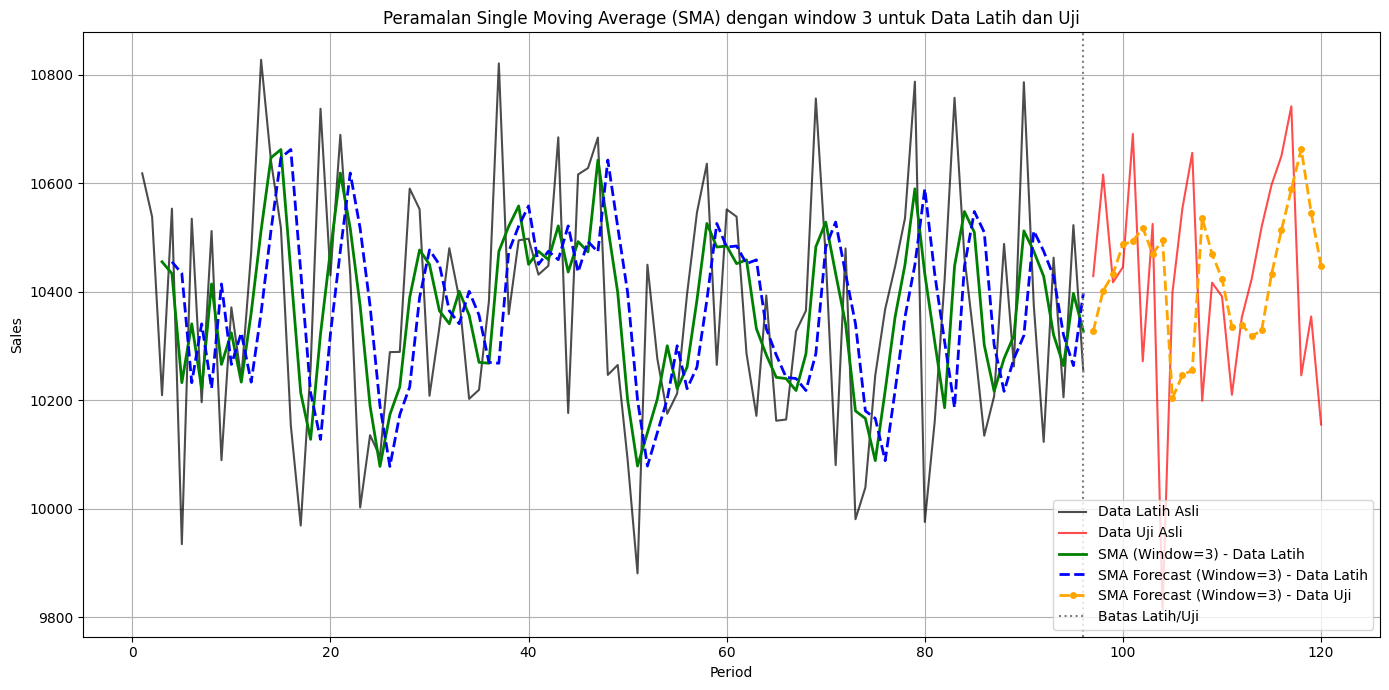

In [10]:
# ============================================================
# PLOT HASIL PERAMALAN SMA
# ============================================================

plt.figure(figsize=(14, 7))

# Data latih aktual
plt.plot(
    train_data_sma.Period,
    train_data_sma.Sales,
    label='Data Latih Asli',
    color='black',
    alpha=0.7
)

# Data uji aktual
plt.plot(
    test_data_sma.Period,
    test_data_sma.Sales,
    label='Data Uji Asli',
    color='red',
    alpha=0.7
)

# SMA data latih
plt.plot(
    train_data_sma.Period[
        ~train_data_sma['SMA'].isnull()
    ],
    train_data_sma['SMA'][
        ~train_data_sma['SMA'].isnull()
    ],
    label=f'SMA (Window={window}) - Data Latih',
    color='green',
    linestyle='-',
    linewidth=2
)

# Forecast SMA data latih
plt.plot(
    train_data_sma.Period,
    train_data_forecast,
    label=f'SMA Forecast (Window={window}) - Data Latih',
    color='blue',
    linestyle='--',
    linewidth=2
)

# Forecast SMA data uji
plt.plot(
    test_data_sma.Period,
    test_data_forecast,
    label=f'SMA Forecast (Window={window}) - Data Uji',
    color='orange',
    linestyle='--',
    marker='o',
    markersize=4,
    linewidth=2
)

# Batas train dan test
plt.axvline(
    x=train_data_sma.Period.iloc[-1],
    color='grey',
    linestyle=':',
    label='Batas Latih/Uji'
)

plt.title(
    f'Peramalan Single Moving Average (SMA) '
    f'dengan window {window} untuk Data Latih dan Uji'
)

plt.xlabel('Period')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()